<a href="https://colab.research.google.com/github/anuskasthapit98/Machine-Learning/blob/practice/Weeks8_KmeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1️⃣ Setup – Importing Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

2️⃣ Worked Example – Small 2D Dataset


2.1 Create the Dataset

In [2]:
# Create a small 2D dataset (8 points)
data = np.array([
    [2, 10],  # A
    [2, 5],   # B
    [8, 4],   # C
    [5, 8],   # D
    [7, 5],   # E
    [6, 4],   # F
    [1, 2],   # G
    [4, 9]    # H
])

print("Our dataset (8 points):")
print(data)

Our dataset (8 points):
[[ 2 10]
 [ 2  5]
 [ 8  4]
 [ 5  8]
 [ 7  5]
 [ 6  4]
 [ 1  2]
 [ 4  9]]


2.2 Plot Raw Data


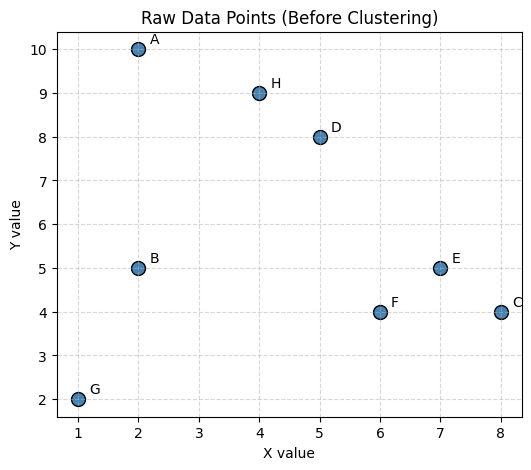

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1],
            s=100, color='steelblue', edgecolors='black')

labels_abc = list("ABCDEFGH")

for i, (x, y) in enumerate(data):
    plt.annotate(labels_abc[i], (x, y),
                 textcoords="offset points", xytext=(8, 4))

plt.xlabel("X value")
plt.ylabel("Y value")
plt.title("Raw Data Points (Before Clustering)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

3️⃣ Elbow Method (Toy Dataset)


k=1 -> WCSS = 100.75
k=2 -> WCSS = 56.27
k=3 -> WCSS = 14.33
k=4 -> WCSS = 9.33


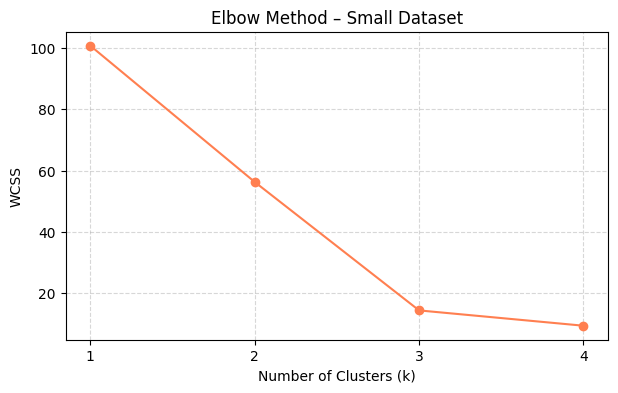

In [4]:
wcss = []

for k in range(1, 5):
    kmeans = KMeans(n_clusters=k, random_state=605)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
    print(f"k={k} -> WCSS = {kmeans.inertia_:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 5), wcss, marker='o', color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method – Small Dataset")
plt.xticks(range(1, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4️⃣ Fit K-Means (k = 3) – Toy Data


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data)

print("Cluster assignments:")
for i, (point, label) in enumerate(zip(data, labels)):
    print(f"Point {labels_abc[i]} {point} -> Cluster {label}")

print("\nCluster centroids:")
print(kmeans.cluster_centers_)

Cluster assignments:
Point A [ 2 10] -> Cluster 1
Point B [2 5] -> Cluster 2
Point C [8 4] -> Cluster 0
Point D [5 8] -> Cluster 1
Point E [7 5] -> Cluster 0
Point F [6 4] -> Cluster 0
Point G [1 2] -> Cluster 2
Point H [4 9] -> Cluster 1

Cluster centroids:
[[7.         4.33333333]
 [3.66666667 9.        ]
 [1.5        3.5       ]]


5️⃣ Visualise Toy Clusters


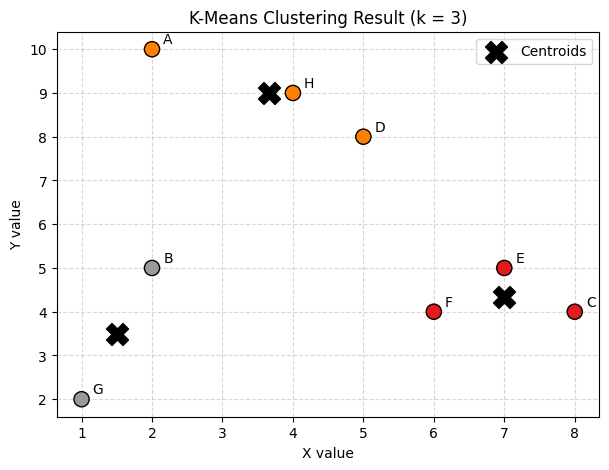

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data[:, 0], data[:, 1],
    c=labels,
    cmap='Set1',
    s=120,
    edgecolors='black',
    zorder=2
)

for i, (x, y) in enumerate(data):
    plt.annotate(labels_abc[i], (x, y),
                 textcoords="offset points", xytext=(8, 4))

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=250,
    color='black',
    label='Centroids',
    zorder=3
)

plt.xlabel("X value")
plt.ylabel("Y value")
plt.title("K-Means Clustering Result (k = 3)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

6️⃣ Real World Example – BMX Dataset


6.1 Load Data

In [8]:
df = pd.read_csv("BMX_G.csv")

print("First 5 rows:")
print(df.head())

print(f"\nDataset size: {df.shape[0]} rows x {df.shape[1]} columns")


First 5 rows:
   Unnamed: 0   seqn  bmdstats  bmxwt  bmiwt  bmxrecum  bmirecum  bmxhead  \
0           1  62161         1   69.2    NaN       NaN       NaN      NaN   
1           2  62162         1   12.7    NaN      95.7       NaN      NaN   
2           3  62163         1   49.4    NaN       NaN       NaN      NaN   
3           4  62164         1   67.2    NaN       NaN       NaN      NaN   
4           5  62165         1   69.1    NaN       NaN       NaN      NaN   

   bmihead  bmxht  ...  bmxarmc  bmiarmc  bmxwaist  bmiwaist  bmxsad1  \
0      NaN  172.3  ...     32.5      NaN      81.0       NaN     17.7   
1      NaN   94.7  ...     16.6      NaN      45.4       NaN      NaN   
2      NaN  168.9  ...     22.0      NaN      64.6       NaN     15.6   
3      NaN  170.1  ...     29.3      NaN      80.1       NaN     18.3   
4      NaN  159.4  ...     29.7      NaN      86.7       NaN     21.0   

   bmxsad2  bmxsad3  bmxsad4  bmdavsad  bmdsadcm  
0     17.9      NaN      NaN     

6.2 Select Key Variables & Explore


In [9]:
key_vars = df[['bmxleg', 'bmxwaist']]

print("Summary statistics:")
print(key_vars.describe().round(2))

print("\nMissing values:")
print(key_vars.isnull().sum())

print(f"\nRows with at least one missing value: "
      f"{key_vars.isnull().any(axis=1).sum()}")

Summary statistics:
        bmxleg  bmxwaist
count  6955.00   8204.00
mean     38.19     86.22
std       4.06     22.37
min      24.80     38.70
25%      35.50     70.28
50%      38.30     86.90
75%      41.00    101.50
max      52.80    176.00

Missing values:
bmxleg      2383
bmxwaist    1134
dtype: int64

Rows with at least one missing value: 2439


6.3 Clean the Data


In [10]:
rows_before = df.shape[0]

df = df.dropna(subset=['bmxleg', 'bmxwaist'])

rows_after = df.shape[0]
rows_dropped = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Rows dropped: {rows_dropped:,} "
      f"({100 * rows_dropped / rows_before:.1f}%)")

Rows before cleaning: 9,338
Rows after cleaning: 6,899
Rows dropped: 2,439 (26.1%)


6.4 Extract Clustering Variables


In [11]:
points = df[['bmxleg', 'bmxwaist']].values

x = points[:, 0]
y = points[:, 1]

print(f"Clustering array shape: {points.shape}")
print(f"Participants: {points.shape[0]:,}")
print("\nFirst 5 rows:")
print(points[:5])

Clustering array shape: (6899, 2)
Participants: 6,899

First 5 rows:
[[40.2 81. ]
 [40.3 64.6]
 [40.5 80.1]
 [42.1 86.7]
 [31.  59.8]]


6.5 Plot Raw BMX Data


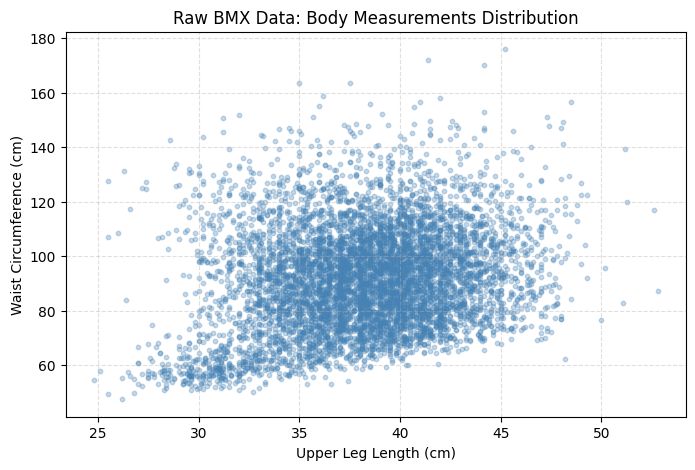

Plotting 6,899 participants.


In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(
    x, y,
    s=10,
    alpha=0.3,
    color='steelblue'
)

plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Waist Circumference (cm)")
plt.title("Raw BMX Data: Body Measurements Distribution")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print(f"Plotting {len(x):,} participants.")


7️⃣ Elbow Method – BMX Dataset


k=1 -> Inertia = 2,524,020
k=2 -> Inertia = 968,523
k=3 -> Inertia = 554,053
k=4 -> Inertia = 377,434
k=5 -> Inertia = 282,095
k=6 -> Inertia = 230,616
k=7 -> Inertia = 194,831
k=8 -> Inertia = 171,359
k=9 -> Inertia = 154,712


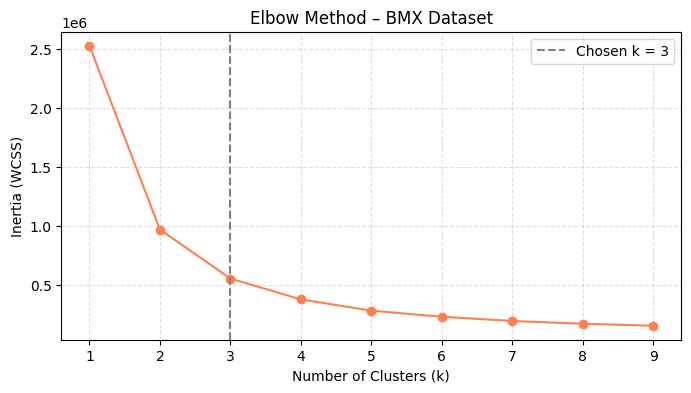

In [14]:
inertias = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=605)
    kmeans.fit(points)
    inertias.append(kmeans.inertia_)
    print(f"k={k} -> Inertia = {kmeans.inertia_:,.0f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='coral')
plt.axvline(x=3, color='grey', linestyle='--', label='Chosen k = 3')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method – BMX Dataset")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

8️⃣ Fit K-Means (k = 3) – BMX Data


In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(points)

unique, counts = np.unique(cluster_labels, return_counts=True)

print("Participants per cluster:")
for cid, count in zip(unique, counts):
    print(f"Cluster {cid}: {count:,} "
          f"({100 * count / len(cluster_labels):.1f}%)")

Participants per cluster:
Cluster 0: 2,463 (35.7%)
Cluster 1: 1,406 (20.4%)
Cluster 2: 3,030 (43.9%)


9️⃣ Visualise BMX Clusters


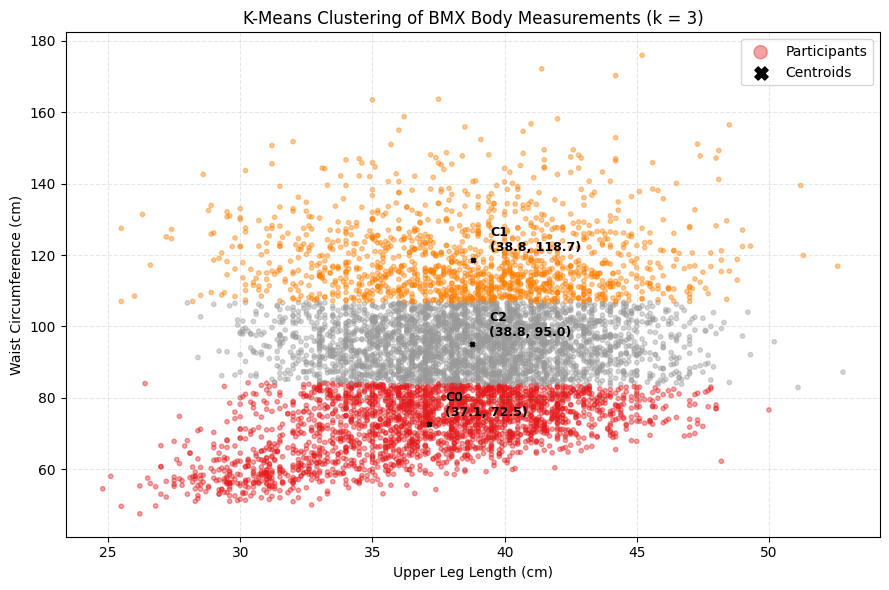

In [17]:

# Scatter plot with cluster colours
plt.figure(figsize=(9, 6))

plt.scatter(
    x, y,
    c=cluster_labels,      # Colour points by cluster
    cmap='Set1',           # Distinct colour palette
    s=10,
    alpha=0.4,
    label='Participants'
)

# Plot the centroids as large black X markers
plt.scatter(
    kmeans.cluster_centers_[:, 0],  # Avg leg length
    kmeans.cluster_centers_[:, 1],  # Avg waist circumference
    marker='X',
    s=10,
    color='black',
    zorder=5,
    label='Centroids'
)

# Annotate centroids with their coordinates
for i, (cx, cy) in enumerate(kmeans.cluster_centers_):
    plt.annotate(
        f"C{i}\n({cx:.1f}, {cy:.1f})",
        (cx, cy),
        textcoords="offset points",
        xytext=(12, 6),
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Waist Circumference (cm)")
plt.title("K-Means Clustering of BMX Body Measurements (k = 3)")
plt.legend(markerscale=3)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


🔟 Inspect Cluster Centroids (Readable)

In [18]:
print("Cluster Centroids (average measurements):")
print("-" * 50)
print(f"{'Cluster':<10} {'Avg Leg Length (cm)':<25} {'Avg Waist (cm)'}")
print("-" * 50)

for i, (leg, waist) in enumerate(kmeans.cluster_centers_):
    print(f"{i:<10} {leg:<25.2f} {waist:.2f}")

print("-" * 50)

Cluster Centroids (average measurements):
--------------------------------------------------
Cluster    Avg Leg Length (cm)       Avg Waist (cm)
--------------------------------------------------
0          37.13                     72.55
1          38.82                     118.69
2          38.78                     95.02
--------------------------------------------------


1️⃣1️⃣ Compare Different Values of k

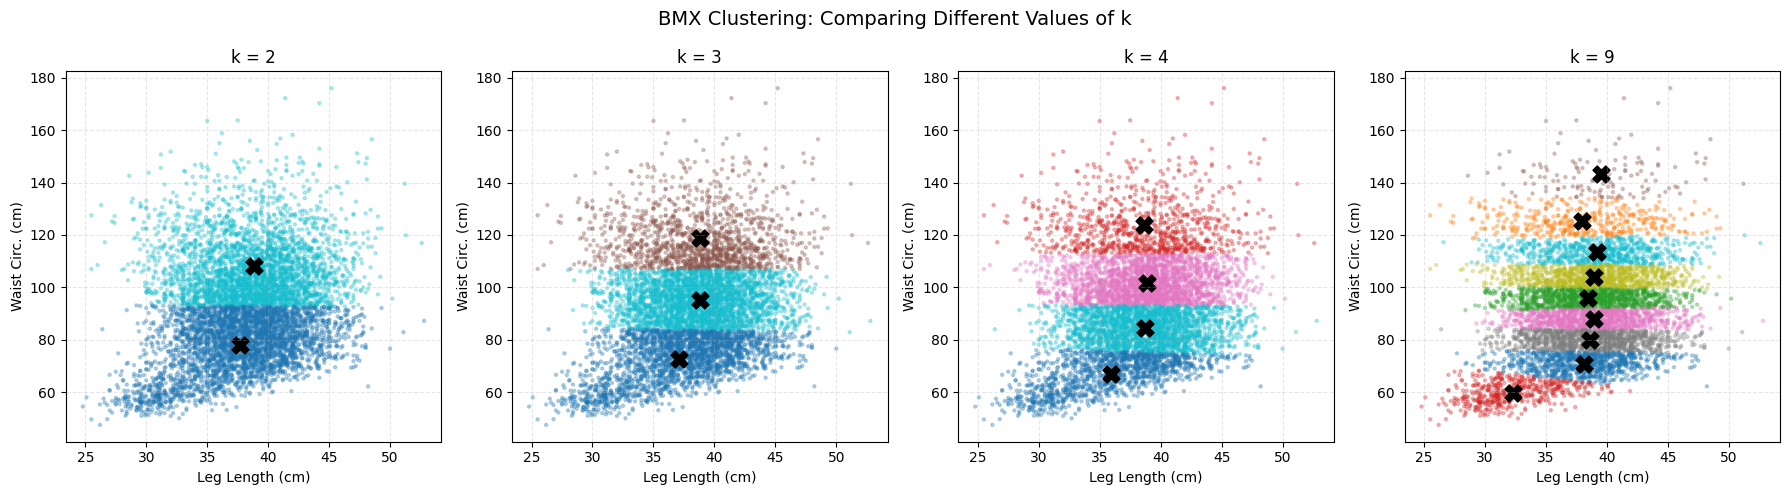

In [19]:
k_values = [2, 3, 4, 9]
fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5))

for ax, k in zip(axes, k_values):
    km = KMeans(n_clusters=k, random_state=42)
    cl = km.fit_predict(points)

    ax.scatter(x, y, c=cl, cmap='tab10', s=5, alpha=0.3)
    ax.scatter(
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        marker='X', s=150, color='black'
    )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("Leg Length (cm)")
    ax.set_ylabel("Waist Circ. (cm)")
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle("BMX Clustering: Comparing Different Values of k", fontsize=14)
plt.tight_layout()
plt.show()